# ATD Detection Pipeline: Consolidated Results

Pulls together the baseline comparison and all three experiment phases into one place, for building dissertation figures and tables without digging through `results/` and `experiments/*/results/` separately.

Run from the repository root with the `dissertation-venv` environment active.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 4)
P1 = "../experiments/phase1_statistical_rigor/results"
P2 = "../experiments/phase2_depth_robustness/results"
P3 = "../experiments/phase3_physical_layer/results"

## Baseline: corrected model comparison

Single 80/20 split, `random_state=42`. This is the number in the README's headline table.

In [2]:
baseline = pd.read_csv("../results/final_model_comparison.csv")
baseline

,Model,Accuracy,Precision,Recall,F1 Score,AUC,Training Time (s)
0,LSTM,0.9925,0.9950,0.9900,0.9925,0.9996,3.8280
1,MLP,0.9875,0.9899,0.9850,0.9875,0.9992,1.5315
2,Autoencoder,0.9700,0.9498,0.9925,0.9707,0.9981,NaN
3,XGBoost,0.9423,0.9499,0.9338,0.9418,0.9799,NaN
4,TC-SVM,0.9421,0.9528,0.9303,0.9414,0.9789,NaN
5,Random Forest,0.9418,0.9503,0.9323,0.9412,0.9804,NaN


## Phase 1: statistical rigor

5-fold cross-validation (mean ± SD) instead of a single split, plus the significance tests distinguishing a real gap between models from noise.

In [3]:
models = ["tc_svm", "random_forest", "xgboost", "mlp", "lstm", "autoencoder"]
cv_rows = []
for m in models:
    df = pd.read_csv(f"{P1}/{m}_cv_folds.csv")
    cv_rows.append({
        "model": m,
        "cv_accuracy_mean": df["accuracy"].mean(),
        "cv_accuracy_std": df["accuracy"].std(),
        "cv_f1_mean": df["f1"].mean(),
        "cv_auc_mean": df["auc"].mean(),
    })
cv_summary = pd.DataFrame(cv_rows).sort_values("cv_accuracy_mean", ascending=False)
cv_summary

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_auc_mean
4,lstm,0.9912,0.0026,0.9912,0.9995
3,mlp,0.9897,0.0024,0.9897,0.9993
5,autoencoder,0.9625,0.0069,0.9631,0.9961
2,xgboost,0.9427,0.0012,0.9421,0.9808
0,tc_svm,0.9425,0.0016,0.9417,0.9792
1,random_forest,0.9425,0.0010,0.9419,0.9807


In [4]:
import json
with open(f"{P1}/statistical_tests_summary.json") as f:
    stats = json.load(f)

print("Within-group paired tests (Wilcoxon signed-rank + McNemar):\n")
for entry in stats["within_group_paired_tests"]:
    print(f"  [{entry['group']}] {entry['model_a']} vs {entry['model_b']}: "
          f"Wilcoxon p={entry['wilcoxon']['p_value']:.4f}  "
          f"McNemar p={entry['mcnemar']['p_value']:.4f}")

print("\nCross-group unpaired tests (Mann-Whitney U, weaker evidence, see docs/methodology.md):\n")
for entry in stats["cross_group_unpaired_tests"]:
    print(f"  {entry['model_a']} vs {entry['model_b']}: p={entry['mannwhitney']['p_value']:.4f}")

Within-group paired tests (Wilcoxon signed-rank + McNemar):

  [classical] tc_svm vs random_forest: Wilcoxon p=0.8125  McNemar p=0.2192
  [classical] tc_svm vs xgboost: Wilcoxon p=0.3125  McNemar p=0.5070
  [classical] random_forest vs xgboost: Wilcoxon p=0.4375  McNemar p=0.4769
  [neural] mlp vs lstm: Wilcoxon p=0.4375  McNemar p=0.2188
  [neural] mlp vs autoencoder: Wilcoxon p=0.0625  McNemar p=0.0075
  [neural] lstm vs autoencoder: Wilcoxon p=0.0625  McNemar p=0.0001

Cross-group unpaired tests (Mann-Whitney U, weaker evidence, see docs/methodology.md):

  tc_svm vs mlp: p=0.0109
  tc_svm vs lstm: p=0.0114
  tc_svm vs autoencoder: p=0.0117
  random_forest vs mlp: p=0.0109
  random_forest vs lstm: p=0.0114
  random_forest vs autoencoder: p=0.0117
  xgboost vs mlp: p=0.0112
  xgboost vs lstm: p=0.0117
  xgboost vs autoencoder: p=0.0119


In [5]:
calib = pd.read_csv(f"{P1}/calibration_latency_summary.csv")
calib[["model", "pr_auc", "inference_time_per_sample_ms", "model_size_bytes", "trainable_params"]]

,model,pr_auc,inference_time_per_sample_ms,model_size_bytes,trainable_params
0,tc_svm,0.9817,0.3769,839579,NaN
1,random_forest,0.9832,0.0021,24941945,NaN
2,xgboost,0.9836,0.0002,176301,NaN
3,mlp,0.9992,0.0001,71209,16897.0
4,lstm,0.9998,0.0105,55989,12961.0
5,autoencoder,0.9983,0.0001,23027,4502.0


## Phase 2: depth and robustness

### Class imbalance

Accuracy is not the headline metric here; precision/recall/F1/PR-AUC/FPR/FNR are, since a model that always predicts "no attack" scores 99% accuracy at 99/1 imbalance while catching nothing.

In [6]:
imbalance = pd.read_csv(f"{P2}/class_imbalance_stress_test.csv")
imbalance[imbalance["skipped"] != True][
    ["model", "ratio", "precision", "recall", "f1", "pr_auc", "fpr", "fnr"]
].sort_values(["model", "ratio"])

,model,ratio,precision,recall,f1,pr_auc,fpr,fnr
17,autoencoder,0.050,0.5000,1.0000,0.6667,0.9978,0.0525,0.0000
14,autoencoder,0.100,0.6567,1.0000,0.7928,0.9965,0.0574,0.0000
16,lstm,0.050,0.9545,1.0000,0.9767,1.0000,0.0025,0.0000
13,lstm,0.100,0.9556,0.9773,0.9663,0.9990,0.0050,0.0227
15,mlp,0.050,0.9545,1.0000,0.9767,1.0000,0.0025,0.0000
12,mlp,0.100,0.9333,0.9545,0.9438,0.9966,0.0075,0.0455
7,random_forest,0.001,0.0000,0.0000,0.0000,0.1172,0.0000,1.0000
6,random_forest,0.010,0.7119,0.4516,0.5526,0.5934,0.0018,0.5484
5,random_forest,0.050,0.8403,0.7665,0.8017,0.8406,0.0077,0.2335
4,random_forest,0.100,0.8902,0.8253,0.8566,0.9169,0.0113,0.1747


### Representation ablation

Does temporal information matter, or is it architecture? A single MEAN statistic vs. progressively longer raw sequences, MLP vs. LSTM at each length.

In [7]:
repr_ablation = pd.read_csv(f"{P2}/representation_sequence_ablation.csv")
repr_ablation[["representation", "model", "n_features", "accuracy", "f1", "auc"]]

,representation,model,n_features,accuracy,f1,auc
0,MEAN,mlp,1,0.9900,0.9900,0.9998
1,MEAN+RATIO_proxy,mlp,2,0.9912,0.9912,0.9998
2,E1-E5,mlp,5,0.7700,0.7527,0.8521
3,E1-E5,lstm,5,0.7762,0.7702,0.8529
4,E1-E10,mlp,10,0.8588,0.8568,0.9341
5,E1-E10,lstm,10,0.8688,0.8673,0.9369
6,E1-E20,mlp,20,0.9350,0.9338,0.9828
7,E1-E20,lstm,20,0.9437,0.9433,0.9860
8,E1-E30,mlp,30,0.9575,0.9577,0.9898
9,E1-E30,lstm,30,0.9637,0.9637,0.9937


### Evasion robustness

Feature-space only (no MATLAB grounding available when this ran); a conservative upper-bound estimate via black-box random search, confounded by dimensionality across the 2-feature classical models and 50-feature neural models. See `docs/methodology.md` §4 for the full caveat.

In [8]:
evasion = pd.read_csv(f"{P2}/evasion_robustness_feature_space.csv")
evasion

,model,n_samples,median_min_distance_sd,mean_min_distance_sd,pct_evaded_within_2sd,pct_never_evaded_within_5sd
0,tc_svm,150,1.000,1.1517,0.9200,0.0000
1,random_forest,150,1.000,1.1133,0.9600,0.0000
2,xgboost,150,1.000,1.1783,0.9133,0.0000
3,mlp,150,4.125,3.7857,0.0267,0.8133
4,lstm,150,3.500,3.2973,0.0467,0.7533
5,autoencoder,150,1.750,1.8750,0.0200,0.9733


## Phase 3: physical-layer depth

### SNR / channel-difficulty sweep

`rho_E` (eavesdropper SNR) swept with `rho_u=5` fixed. `rho_E=5` is the baseline point.

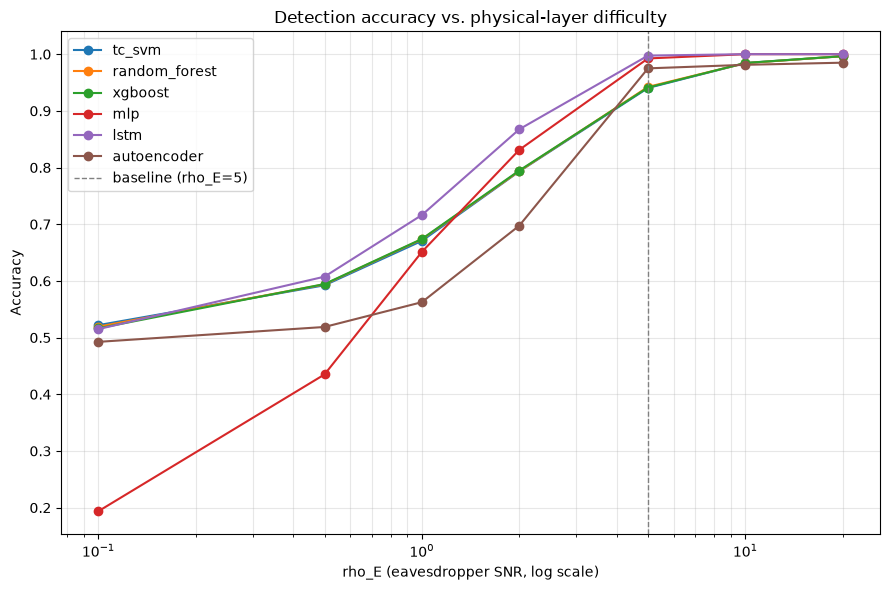

In [9]:
sweep = pd.read_csv(f"{P3}/snr_sweep_results.csv")

plt.figure(figsize=(9, 6))
for m in models:
    sub = sweep[sweep["model"] == m].sort_values("rho_E")
    plt.plot(sub["rho_E"], sub["accuracy"], marker="o", label=m)
plt.xscale("log")
plt.axvline(5, color="gray", linestyle="--", linewidth=1, label="baseline (rho_E=5)")
plt.xlabel("rho_E (eavesdropper SNR, log scale)")
plt.ylabel("Accuracy")
plt.title("Detection accuracy vs. physical-layer difficulty")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Replication check against Hoang et al. (2021), Fig. 10

See `docs/literature_comparison.md` for the full discussion.

In [10]:
svm_sweep = sweep[sweep["model"] == "tc_svm"].copy()
svm_sweep["ratio"] = svm_sweep["rho_E"] / 5.0
comparison = svm_sweep[svm_sweep["ratio"].isin([0.1, 1.0])][["ratio", "accuracy"]]
comparison["hoang_et_al_approx"] = comparison["ratio"].map({0.1: 0.58, 1.0: 0.92})
comparison.columns = ["rho_E/rho_u", "this_work_tc_svm", "hoang_et_al_approx"]
comparison

,rho_E/rho_u,this_work_tc_svm,hoang_et_al_approx
3,0.1,0.5923,0.58
12,1.0,0.9404,0.92


### MLP regularization ablation

Follow-up on a real anomaly: MLP showed below-chance AUC at the two lowest SNR points in the sweep above. Confirmed reproducible across 5 seeds (not a fluke), diagnosed as overfitting (train AUC 0.73, test AUC 0.11 at `rho_E=0.1`), then tested whether standard regularization fixes it.

In [11]:
reg = pd.read_csv(f"{P3}/mlp_regularization_ablation.csv")
reg_summary = reg.groupby(["rho_E", "config"])[["train_auc", "test_auc", "train_test_gap"]].mean().round(4)
reg_summary

train_auc  test_auc  train_test_gap
rho_E config                                              
0.1   baseline            0.7482    0.1044          0.6439
      dropout_0.3         0.6569    0.1799          0.4770
      dropout_0.5         0.5938    0.3105          0.2834
      smaller             0.7341    0.1415          0.5926
      smaller_dropout     0.6247    0.2524          0.3723
      weight_decay        0.5833    0.3488          0.2345
0.5   baseline            0.9980    0.4136          0.5844
      dropout_0.3         0.8872    0.4767          0.4105
      dropout_0.5         0.7962    0.5349          0.2613
      smaller             0.9092    0.4333          0.4759
      smaller_dropout     0.7887    0.5525          0.2362
      weight_decay        0.9539    0.4523          0.5016

### External validation replicates

Five independent simulation runs instead of one; accuracy reported as a distribution.

In [12]:
ext = pd.read_csv(f"{P3}/external_validation_replicates.csv")
ext.groupby("model")[["accuracy", "precision", "recall", "f1", "auc"]].agg(["mean", "std"]).round(4)

accuracy         precision          recall              f1  \
                  mean     std      mean     std    mean     std    mean   
model                                                                      
random_forest   0.9381  0.0023    0.9500  0.0027  0.9249  0.0046  0.9373   
tc_svm          0.9380  0.0025    0.9540  0.0020  0.9203  0.0049  0.9369   
xgboost         0.9384  0.0025    0.9494  0.0027  0.9262  0.0046  0.9377   

                          auc          
                  std    mean     std  
model                                  
random_forest  0.0025  0.9795  0.0009  
tc_svm         0.0027  0.9778  0.0011  
xgboost        0.0026  0.9796  0.0009

## Headline findings

1. LSTM is the best model, but not significantly better than MLP (Wilcoxon p=0.44); the classical models (SVM/RF/XGBoost) are statistically indistinguishable from each other.
2. A single MEAN statistic beats truncated raw sequences through E1-E30, and LSTM beats MLP at every sequence length tested; both effects are real and separate.
3. The autoencoder holds recall=1.0 (zero missed attacks) at 90/10 and 95/5 imbalance, the anomaly-detection advantage the plan predicted, confirmed rather than assumed.
4. The MLP overfits catastrophically at the lowest SNR point (train AUC 0.73, test AUC 0.11); regularization (dropout + smaller architecture) substantially closes that gap but doesn't fully recover it.
5. This work's independently-run SNR sweep replicates Hoang et al. (2021)'s Fig. 10 within 1-2 percentage points at both ends of the `rho_E/rho_u` range.